### Mount Google drive and change directory to project

In [1]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# change directory to project
%cd drive/MyDrive/ee546/clip_text_span-main/

/content/drive/MyDrive/ee546/clip_text_span-main


In [3]:
# Initialize Conda and check version
!source /opt/conda/etc/profile.d/conda.sh && conda --version

/bin/bash: line 1: /opt/conda/etc/profile.d/conda.sh: No such file or directory


### Accept Conda Channels's Terms of Service

In [4]:
# accept repo.anaconda.com/pkgs/main  Terms of Service
!source /opt/conda/etc/profile.d/conda.sh && conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main

/bin/bash: line 1: /opt/conda/etc/profile.d/conda.sh: No such file or directory


In [5]:
# accept repo.anaconda.com/pkgs/r Terms of Service
!source /opt/conda/etc/profile.d/conda.sh && conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

/bin/bash: line 1: /opt/conda/etc/profile.d/conda.sh: No such file or directory


### Setup Environment

In [6]:
# environment requirement
!source /opt/conda/etc/profile.d/conda.sh && conda env create -f environment.yml

/bin/bash: line 1: /opt/conda/etc/profile.d/conda.sh: No such file or directory


In [7]:
# activate environment
!source opt/conda/etc/profile.d/conda.sh && conda activate prsclip

/bin/bash: line 1: opt/conda/etc/profile.d/conda.sh: No such file or directory


In [8]:
# install packages
!pip install torch torchvision
!pip install timm einops ftfy regex tqdm
!pip install numpy scipy
!pip install Pillow imageio scikit-image opencv-python
!pip install h5py pandas scikit-learn
!pip install transformers huggingface_hub
!pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00


## Use waterbird dataset instead of ImageNet

In [ ]:
# download waterbird dataset and extract
!wget https://nlp.stanford.edu/data/dro/waterbird_complete95_forest2water2.tar.gz
!tar -xf  waterbird_complete95_forest2water2.tar.gz

--2025-11-18 08:23:01--  https://nlp.stanford.edu/data/dro/waterbird_complete95_forest2water2.tar.gz
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/dro/waterbird_complete95_forest2water2.tar.gz [following]
--2025-11-18 08:23:01--  https://downloads.cs.stanford.edu/nlp/data/dro/waterbird_complete95_forest2water2.tar.gz
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 489698023 (467M) [application/octet-stream]
Saving to: ‘waterbird_complete95_forest2water2.tar.gz.4’

waterbird_complete9 100%[===================>] 467.01M  5.01MB/s    in 88s     

2025-11-18 08:24:29 (5.31 MB/s) - ‘waterbird_com

## Compute overall accuracy

In [ ]:
# compute overall accuracy
!python compute_prs.py --dataset binary_waterbirds --device cuda:0 --model ViT-L-14 --pretrained laion2b_s32b_b82k --data_path ./waterbird_complete95_forest2water2/
!python compute_text_projection.py  --dataset binary_waterbirds --device cuda:0 --model ViT-L-14 --pretrained laion2b_s32b_b82k
!python compute_use_specific_heads.py --model ViT-L-14 --dataset binary_waterbirds


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
open_clip_pytorch_model.bin: 100% 1.71G/1.71G [00:06<00:00, 272MB/s]
Model parameters: 427,616,513
Context length: 77
Vocab size: 49408
Len of res: 24
100% 2897/2897 [2:58:17<00:00,  3.69s/it]
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Model parameters: 427,616,513
Context length: 77
Vocab size: 49408
/content/drive/MyDrive/ee546/clip_text_span-main/compute_text_projection.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args..

## Compute Text Set Projection

In [ ]:
!python compute_text_set_projection.py \
    --device cuda:0 \
    --model ViT-L-14 \
    --pretrained laion2b_s32b_b82k \
    --data_path text_descriptions/image_descriptions_general.txt \
    --output_dir ./output_dir

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Model parameters: 427,616,513
Context length: 77
Vocab size: 49408
/content/drive/MyDrive/ee546/clip_text_span-main/compute_text_set_projection.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():
100% 2/2 [00:03<00:00,  1.97s/it]


## Select by user
user can select the which head should be ablated

1. select last 2 layers
2. select last 4 layers
3. select last 6 layers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# strategy 4 - select by user
!python select_ablated_heads.py \
    --model ViT-L-14 \
    --dataset binary_waterbirds \
    --input_dir ./output_dir \
    --output_dir ./output_dir/comparison/ \
    --num_last_layers 2

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
SELECT HEADS AND RUN ABLATION

Loading attention features from: ./output_dir/binary_waterbirds_attn_ViT-L-14.npy
Model structure: 24 layers, 16 heads per layer
Analyzing last 2 layers: [22, 23]
Loading text features from: ./output_dir/image_descriptions_general_ViT-L-14.npy
Loading text descriptions from: text_descriptions/image_descriptions_general.txt

Computing top 1 text span for all heads in last 2 layers...
/content/drive/MyDrive/ee546/clip_text_span-main/compute_complete_text_set.py:37: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.aran

In [ ]:
# strategy 4 - select by user
!python select_ablated_heads.py \
    --model ViT-L-14 \
    --dataset binary_waterbirds \
    --input_dir ./output_dir \
    --output_dir ./output_dir/comparison/ \
    --num_last_layers 4

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
SELECT HEADS AND RUN ABLATION

Loading attention features from: ./output_dir/binary_waterbirds_attn_ViT-L-14.npy
Model structure: 24 layers, 16 heads per layer
Analyzing last 4 layers: [20, 21, 22, 23]
Loading text features from: ./output_dir/image_descriptions_general_ViT-L-14.npy
Loading text descriptions from: text_descriptions/image_descriptions_general.txt

Computing top 1 text span for all heads in last 4 layers...
/content/drive/MyDrive/ee546/clip_text_span-main/compute_complete_text_set.py:37: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*to

In [ ]:
!python select_ablated_heads.py \
    --model ViT-L-14 \
    --dataset binary_waterbirds \
    --input_dir ./output_dir \
    --output_dir ./output_dir/comparison/ \
    --num_last_layers 6

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
SELECT HEADS AND RUN ABLATION

Loading attention features from: ./output_dir/binary_waterbirds_attn_ViT-L-14.npy
Model structure: 24 layers, 16 heads per layer
Analyzing last 6 layers: [18, 19, 20, 21, 22, 23]
Loading text features from: ./output_dir/image_descriptions_general_ViT-L-14.npy
Loading text descriptions from: text_descriptions/image_descriptions_general.txt

Computing top 1 text span for all heads in last 6 layers...
/content/drive/MyDrive/ee546/clip_text_span-main/compute_complete_text_set.py:37: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.per

## Ablation Strategy Comparison - Analysis Summary

### Overview

This document summarizes four key analyses comparing different ablation strategies for removing spurious correlations in CLIP models on the Waterbirds dataset.

---


In [ ]:
!python compare_ablation_strategies.py \
    --model ViT-L-14 \
    --dataset binary_waterbirds \
    --input_dir ./output_dir/ \
    --output_dir ./output_dir/results \
    --n_clusters 8

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)

Loading baseline...
Baseline accuracy: {'(0, 0)': 94.41241685144124, '(0, 1)': 47.76053215077605, '(1, 0)': 70.56074766355141, '(1, 1)': 93.30218068535827, 'full': 73.48981705212289}

Running 22 experiments...

Running: Strategy1_heads_only
  Looking for heads file: ./output_dir/heads_projected_results/heads_to_ablate_projected_n8_ViT-L-14.txt
  Strategy: 1
  N_clusters: 8
  ✓ Heads file found
  Loaded 42 heads to ablate
✓ Completed: Strategy1_heads_only
  Accuracy: {'(0, 0)': 95.87583148558758, '(0, 1)': 40.487804878048784, '(1, 0)': 24.45482866043614, '(1, 1)': 79.75077881619937, 'full': 64.61857093545046}
✓ Added Strategy1_heads_only to results

Running: Strategy2_heads_only
  Looking for heads file: ./output_di

## Display results



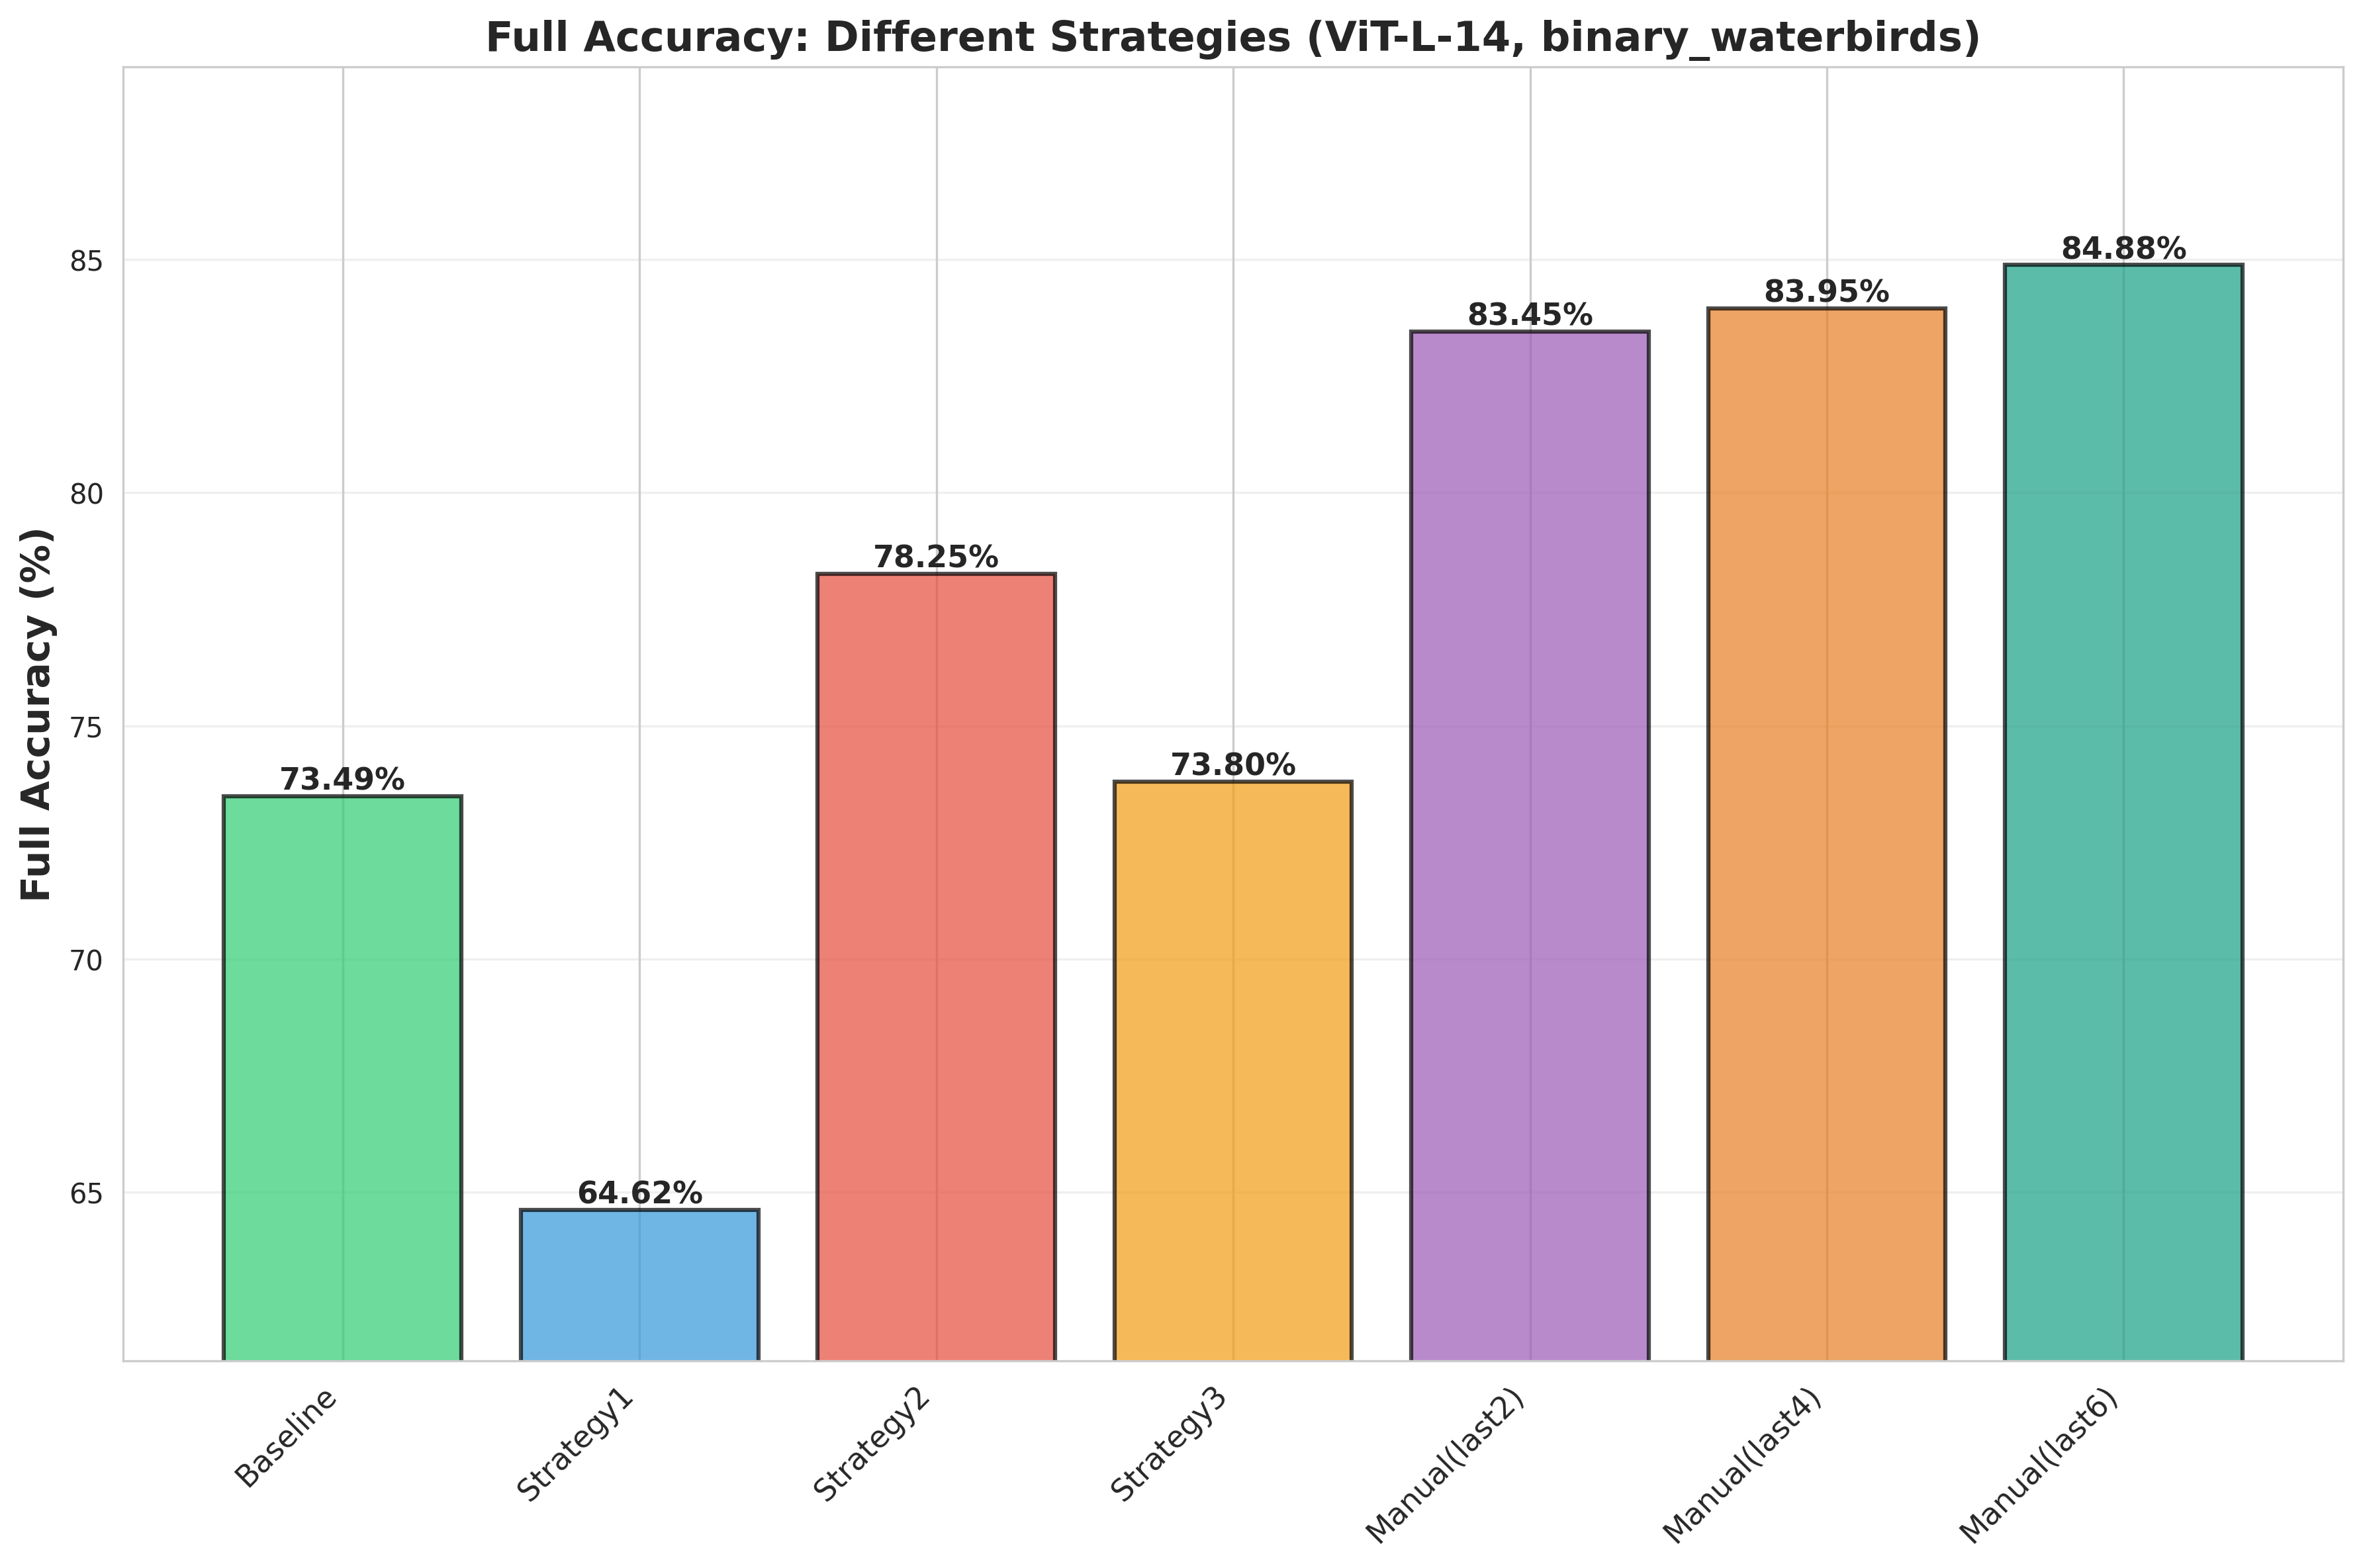

In [ ]:
from IPython.display import Image, display

image_path = './output_dir/results/analysis1_full_accuracy_strategies_ViT-L-14_binary_waterbirds.png'
display(Image(filename=image_path))

Full accuracy comparison across 7 strategies:
- **Baseline** (no ablation)
- **Strategy 1**: Ablate largest cluster (might be spurious correlation)
- **Strategy 2**: Ablate background-related heads
- **Strategy 3**: Ablate representative heads from each cluster
- **Manual selection**: Last 2/4/6 layers

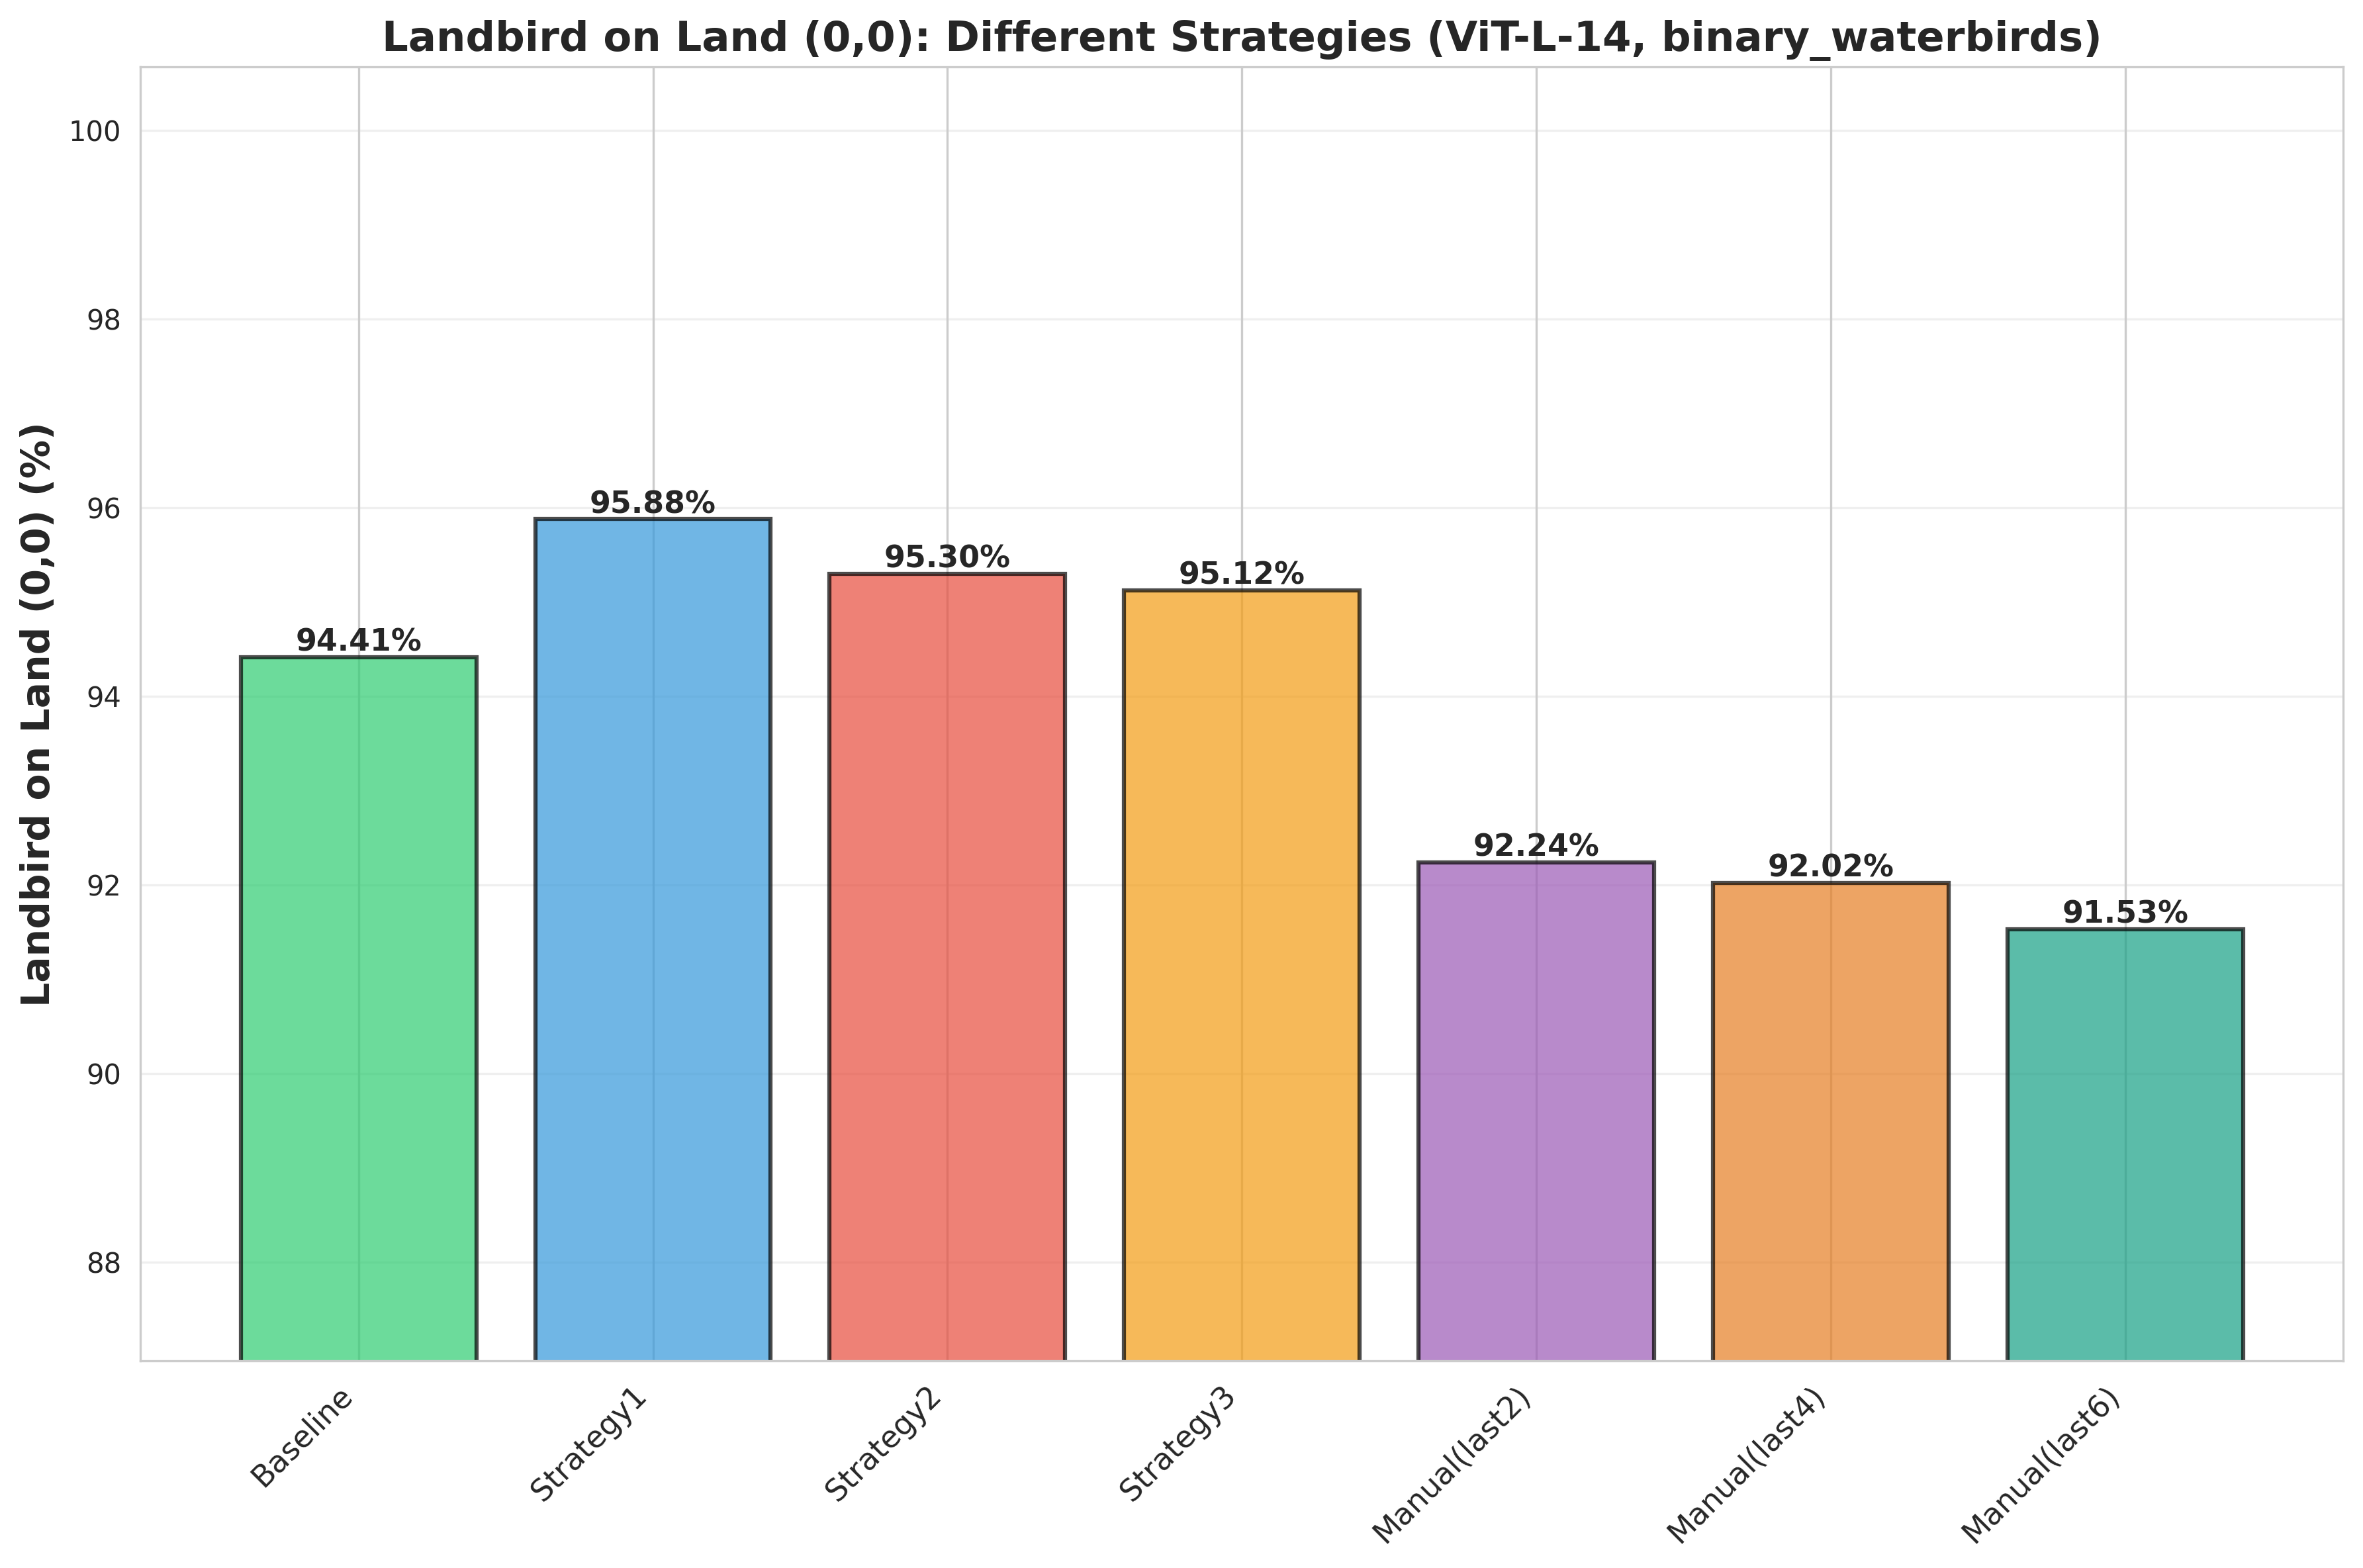

In [ ]:
from IPython.display import Image, display

image_path = './output_dir/results/analysis2_metric_0_0_ViT-L-14_binary_waterbirds.png'
display(Image(filename=image_path))

Accuracy on Landbird on Land

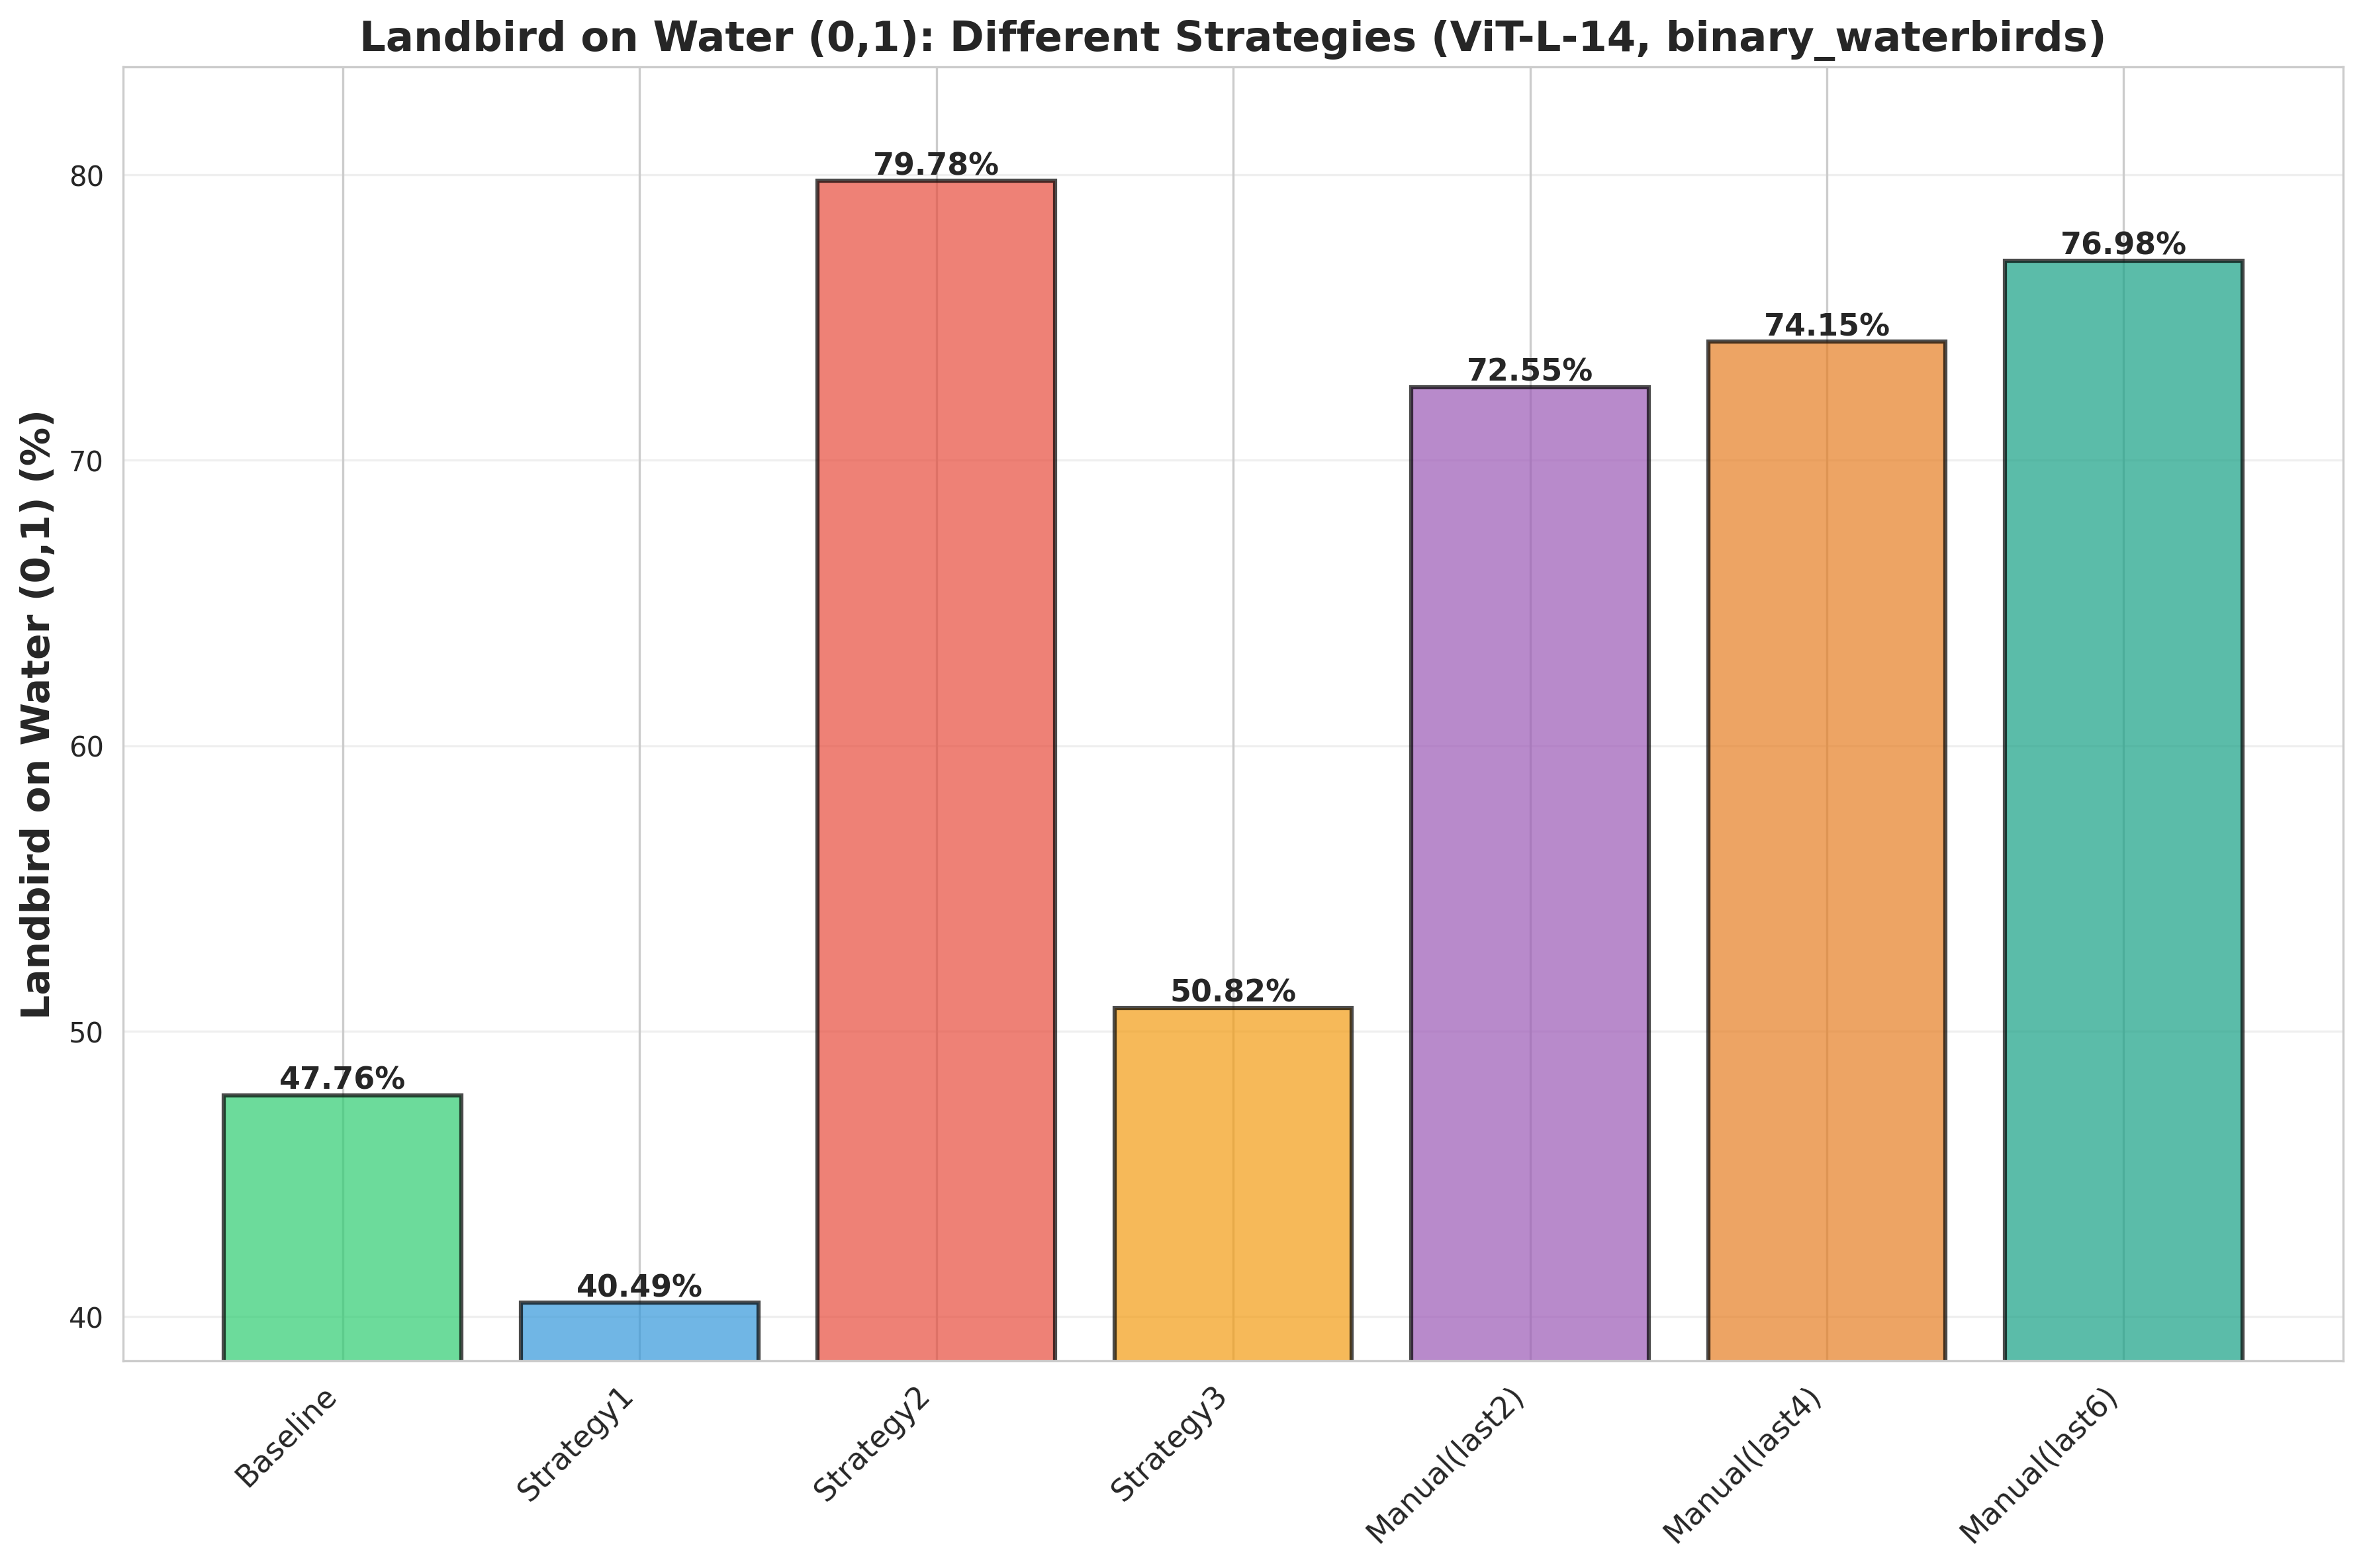

In [ ]:
from IPython.display import Image, display

image_path = './output_dir/results/analysis2_metric_0_1_ViT-L-14_binary_waterbirds.png'
display(Image(filename=image_path))

Accuracy of Landbird on Water

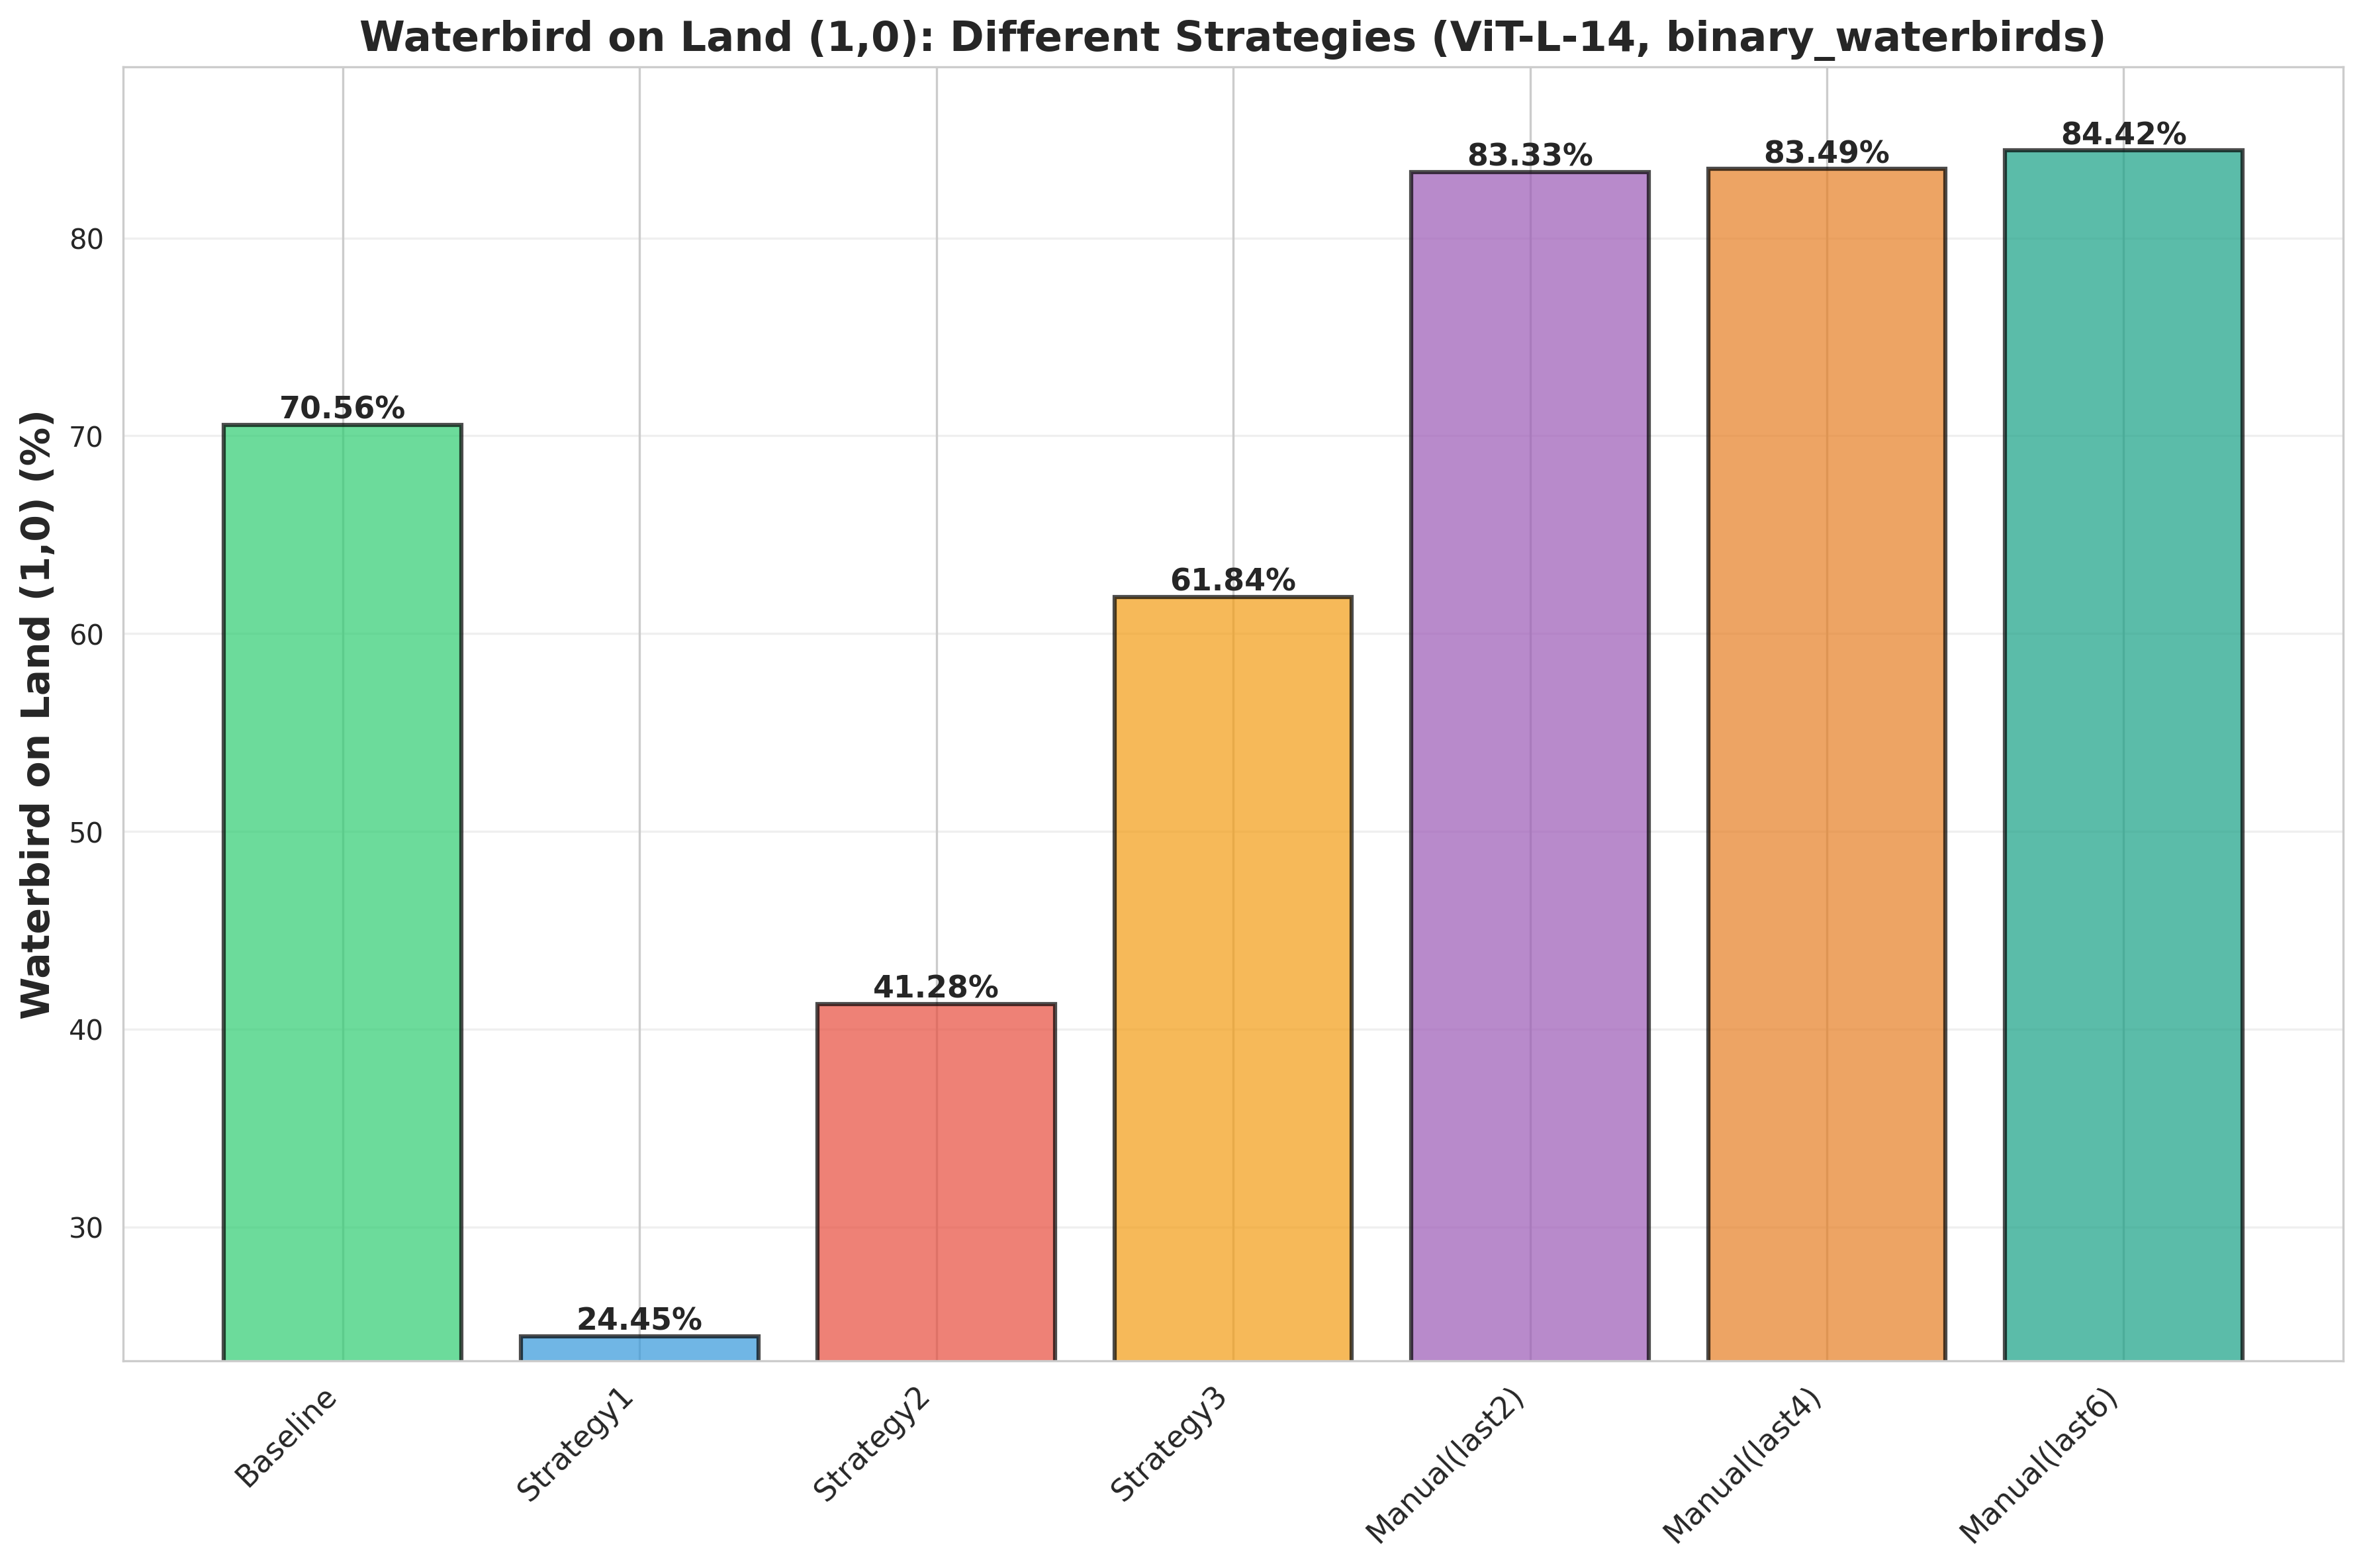

In [ ]:
from IPython.display import Image, display

image_path = './output_dir/results/analysis2_metric_1_0_ViT-L-14_binary_waterbirds.png'
display(Image(filename=image_path))

Accuracy of Waterbird on Land

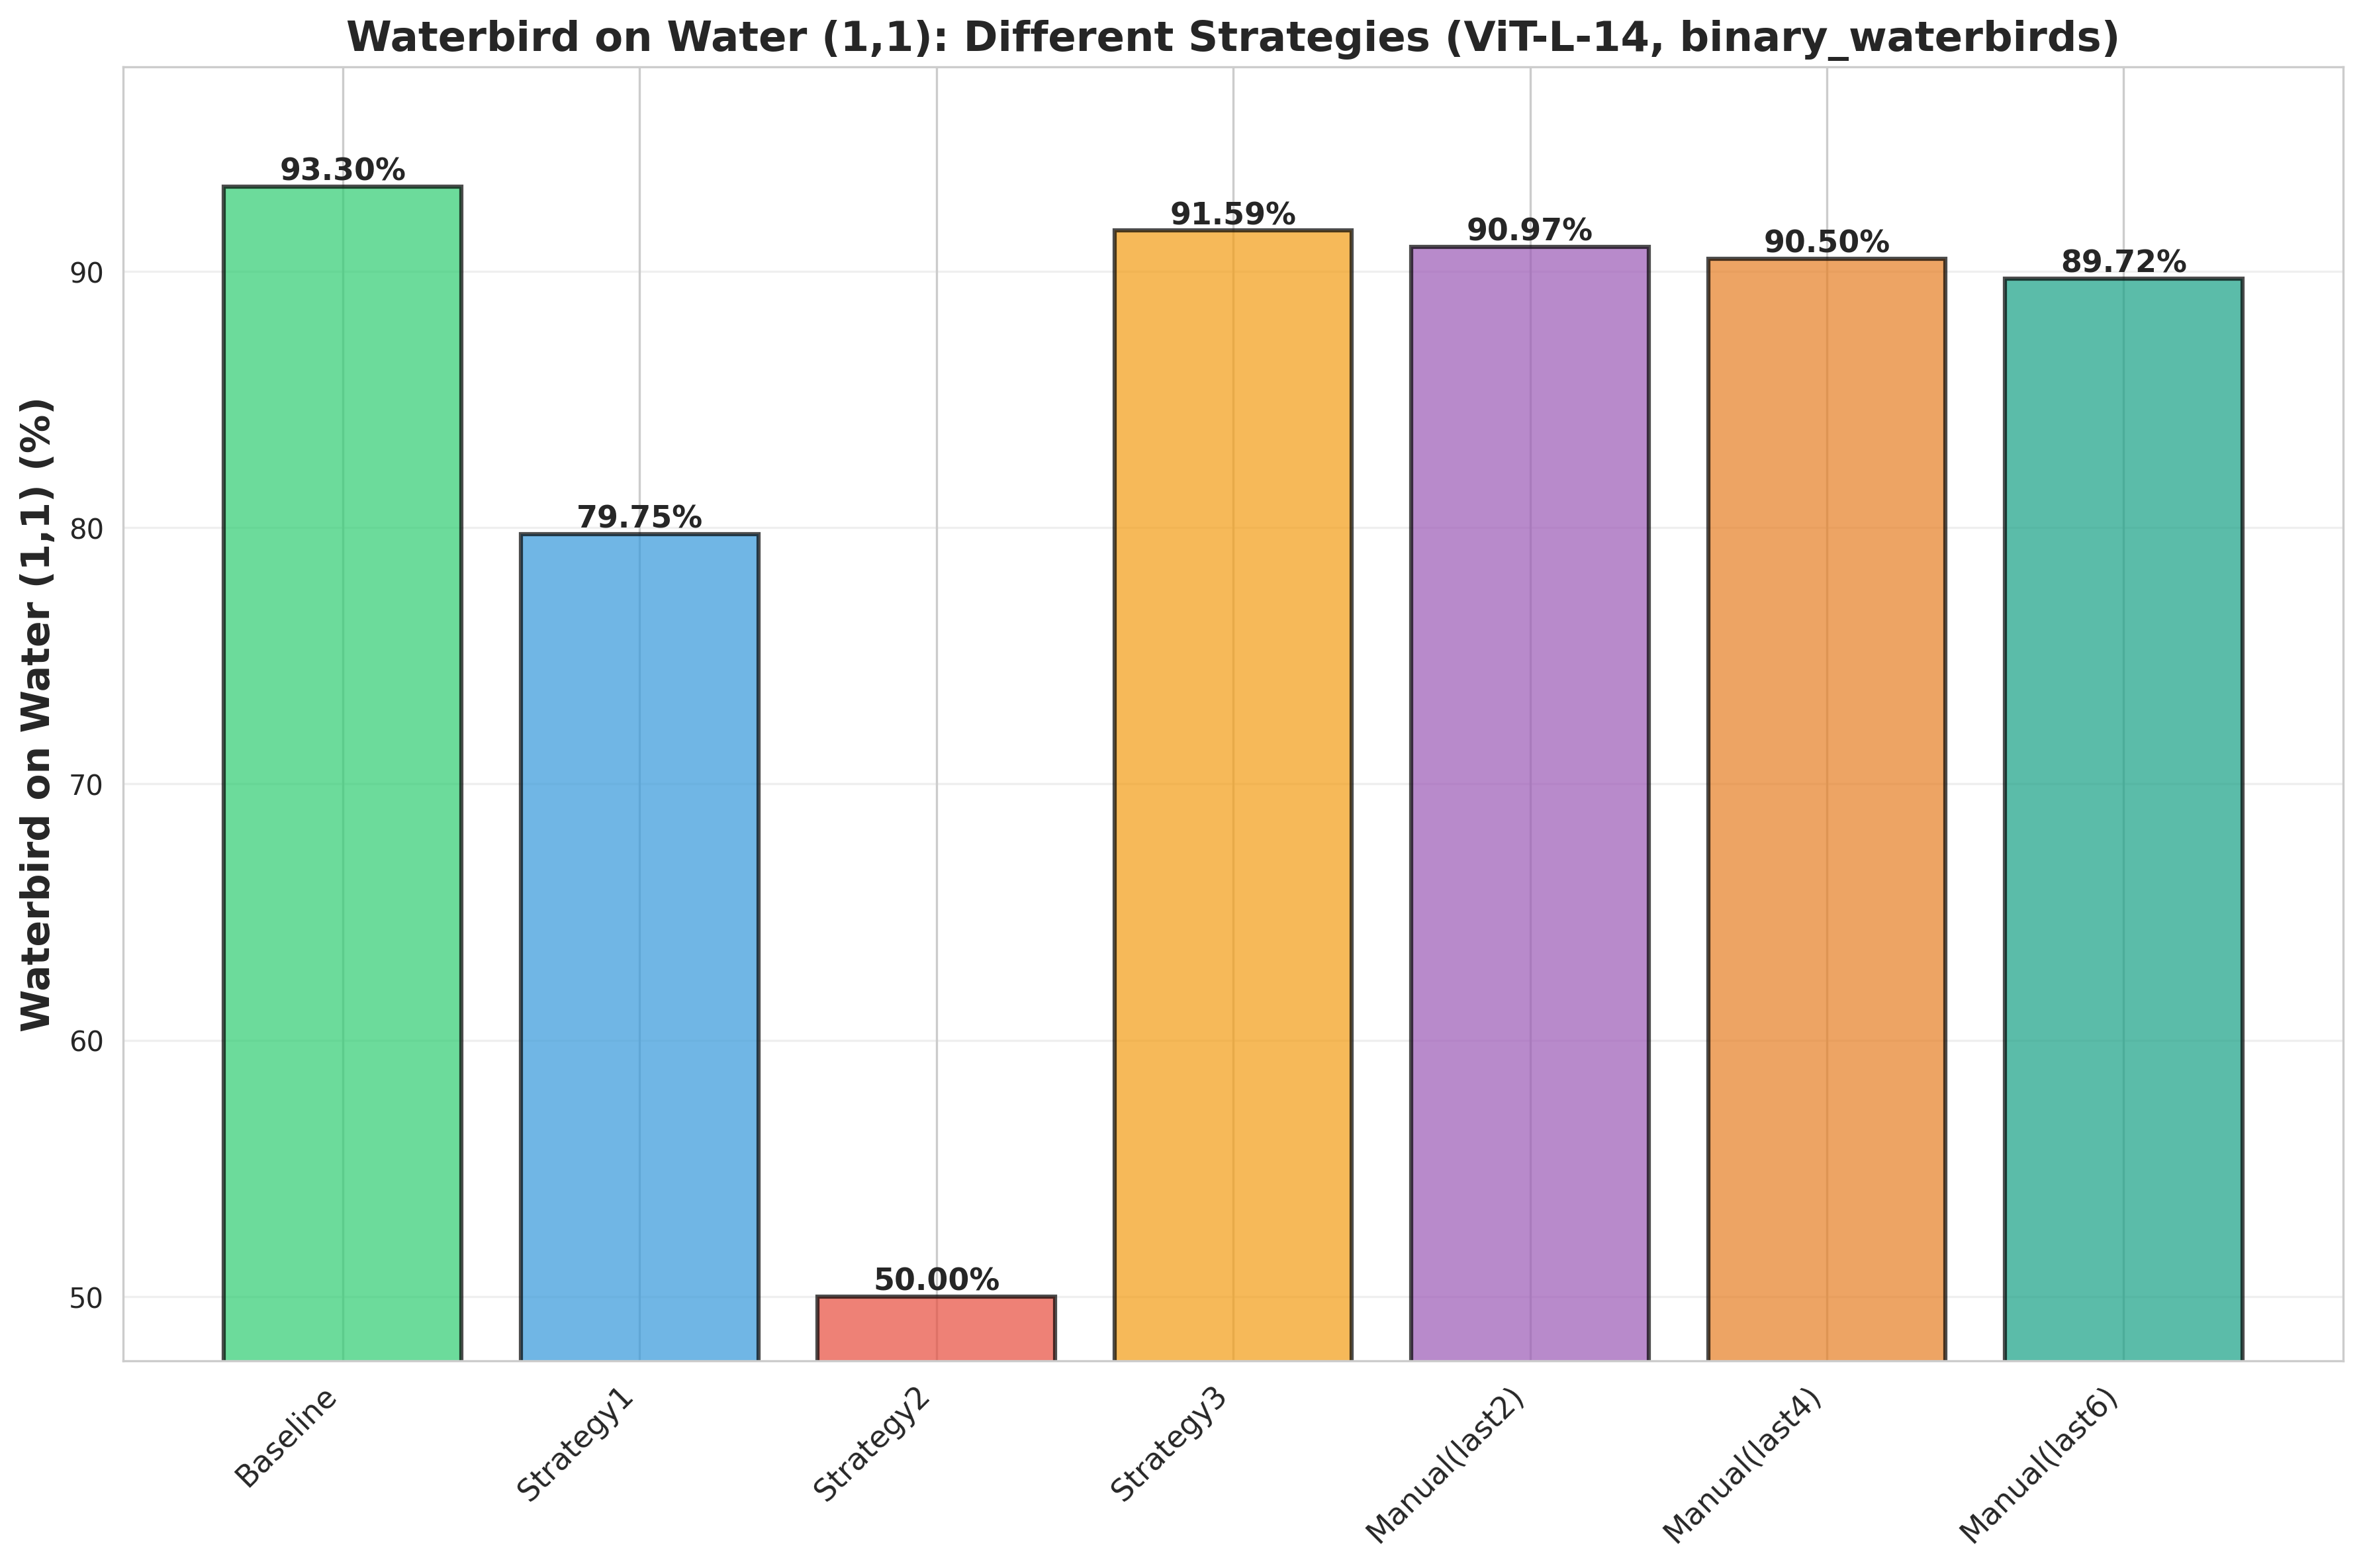

In [ ]:
from IPython.display import Image, display

image_path = './output_dir/results/analysis2_metric_1_1_ViT-L-14_binary_waterbirds.png'
display(Image(filename=image_path))

Accuracy of Waterbird on Water

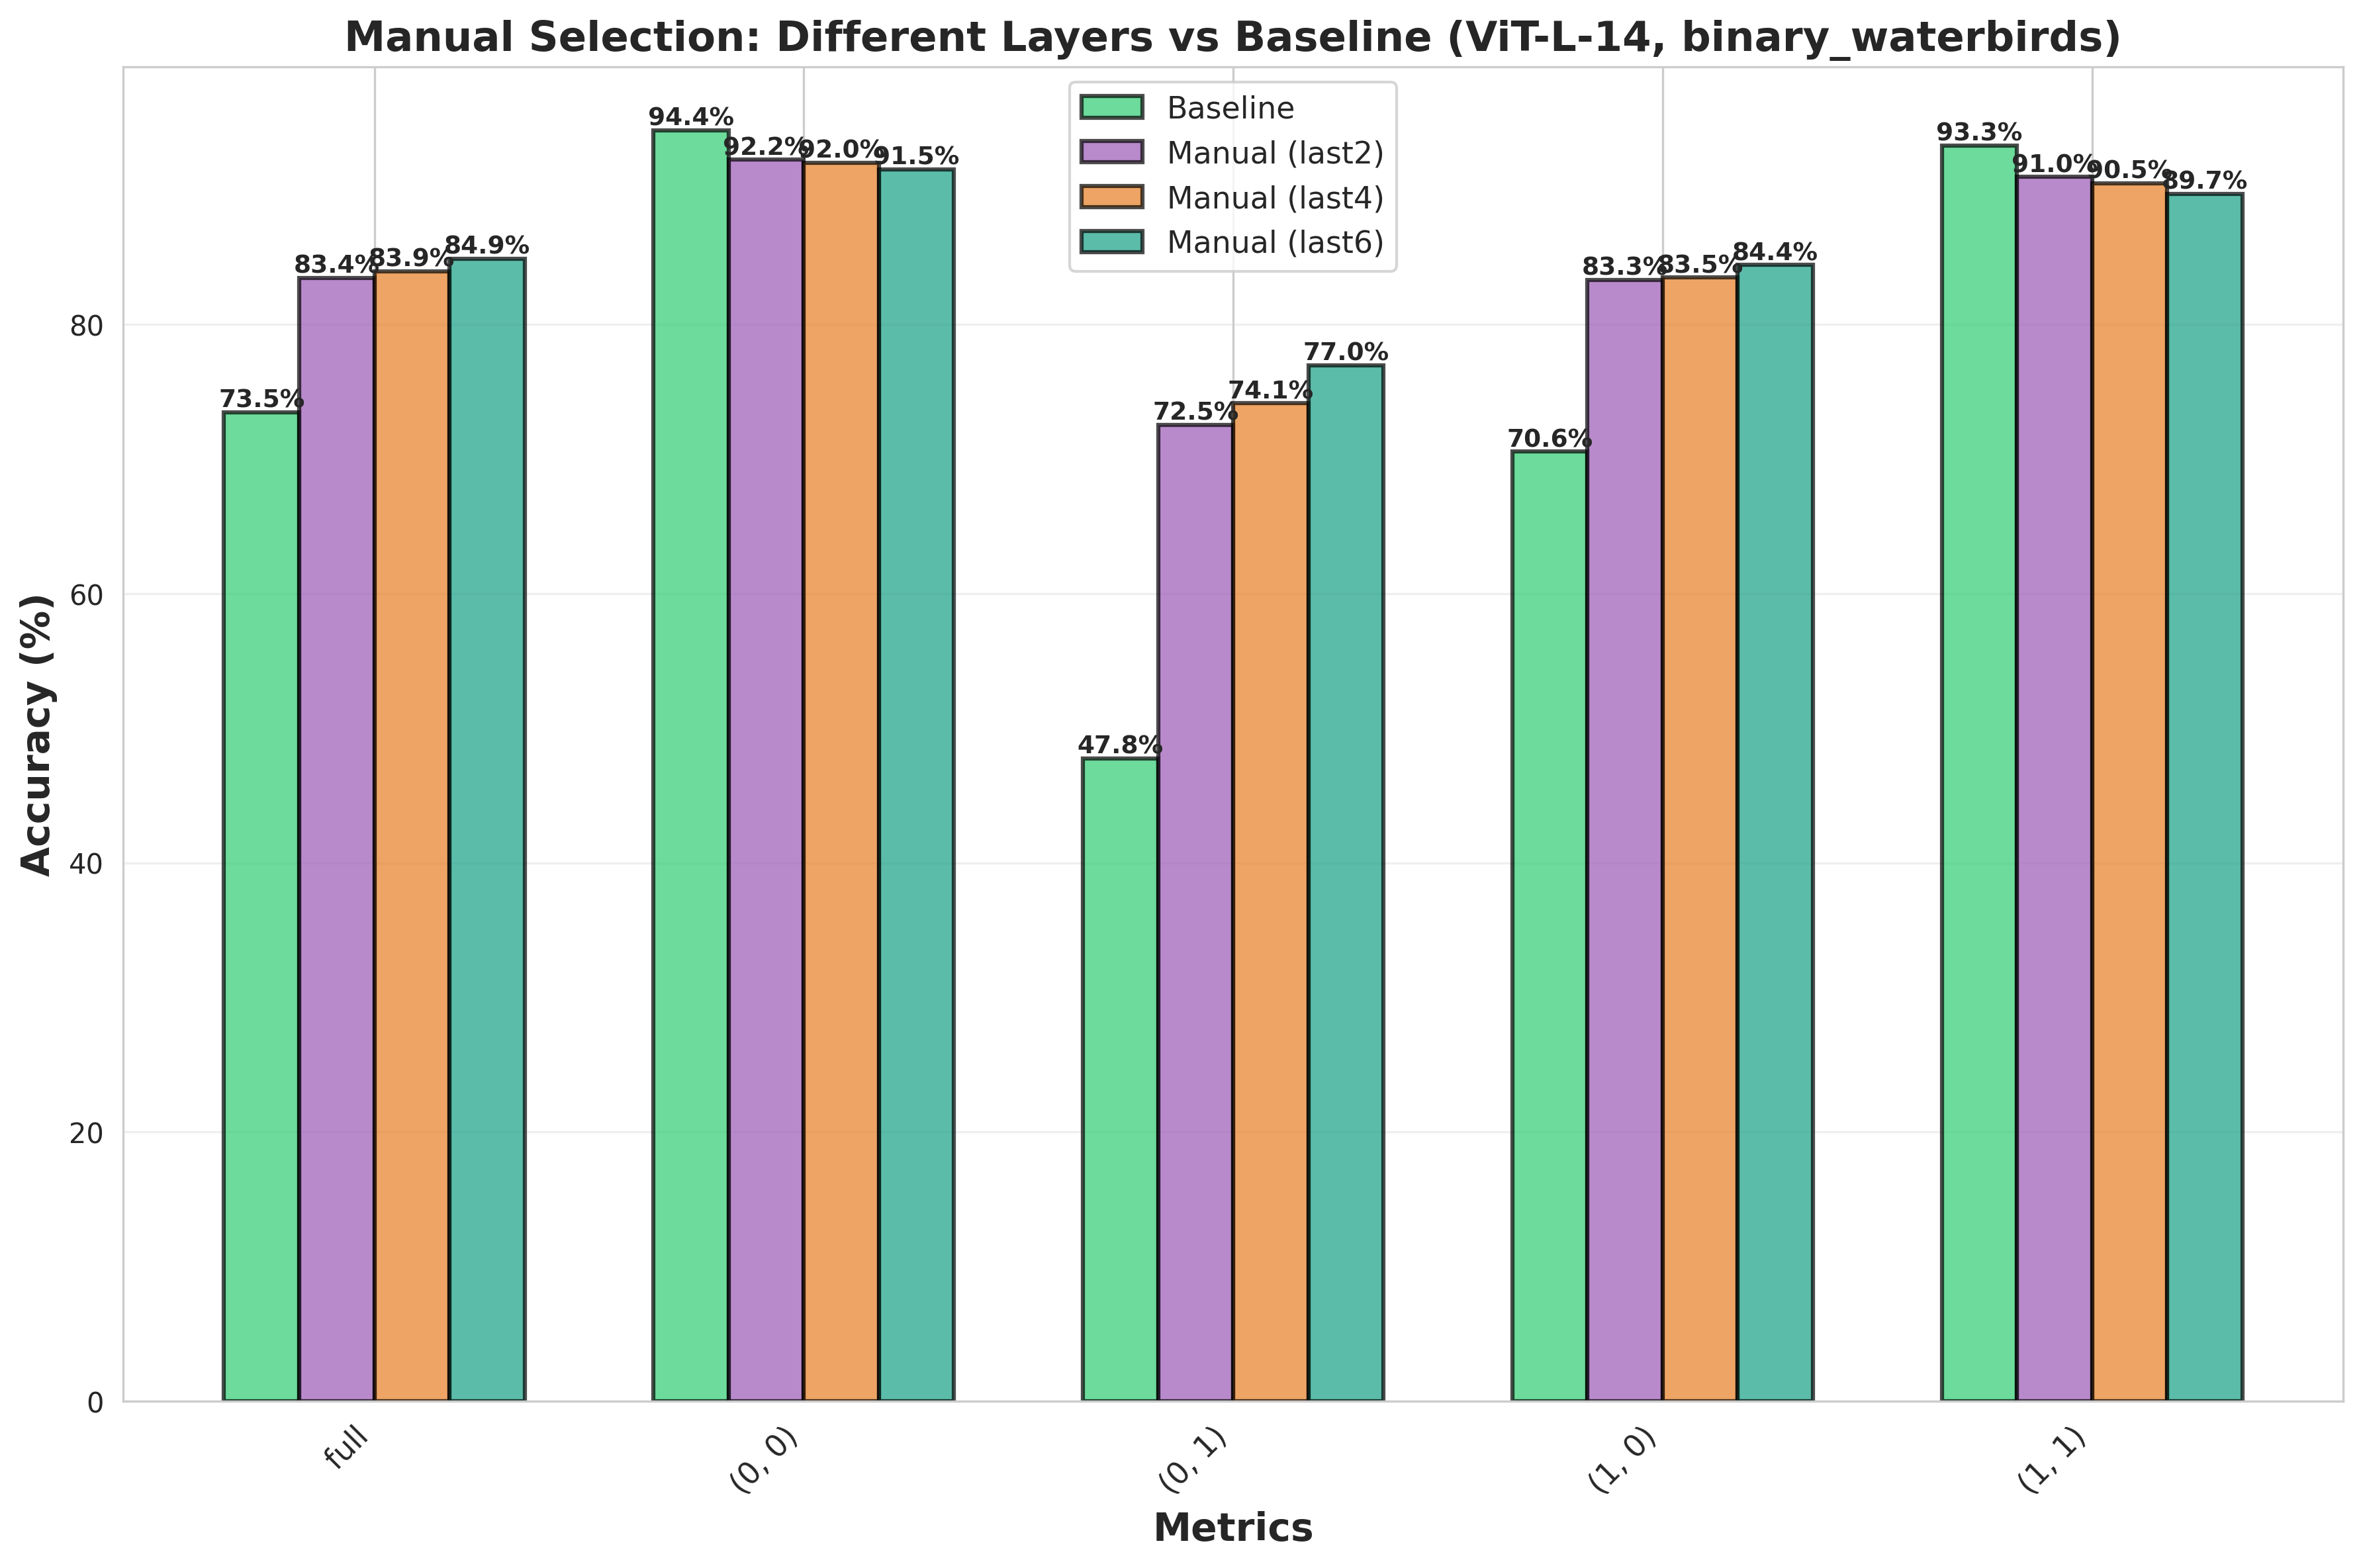

In [ ]:
from IPython.display import Image, display

image_path = './output_dir/results/analysis3_manual_vs_baseline_ViT-L-14_binary_waterbirds.png'
display(Image(filename=image_path))

Compare accuracy between baseline and manually selected ablated heads

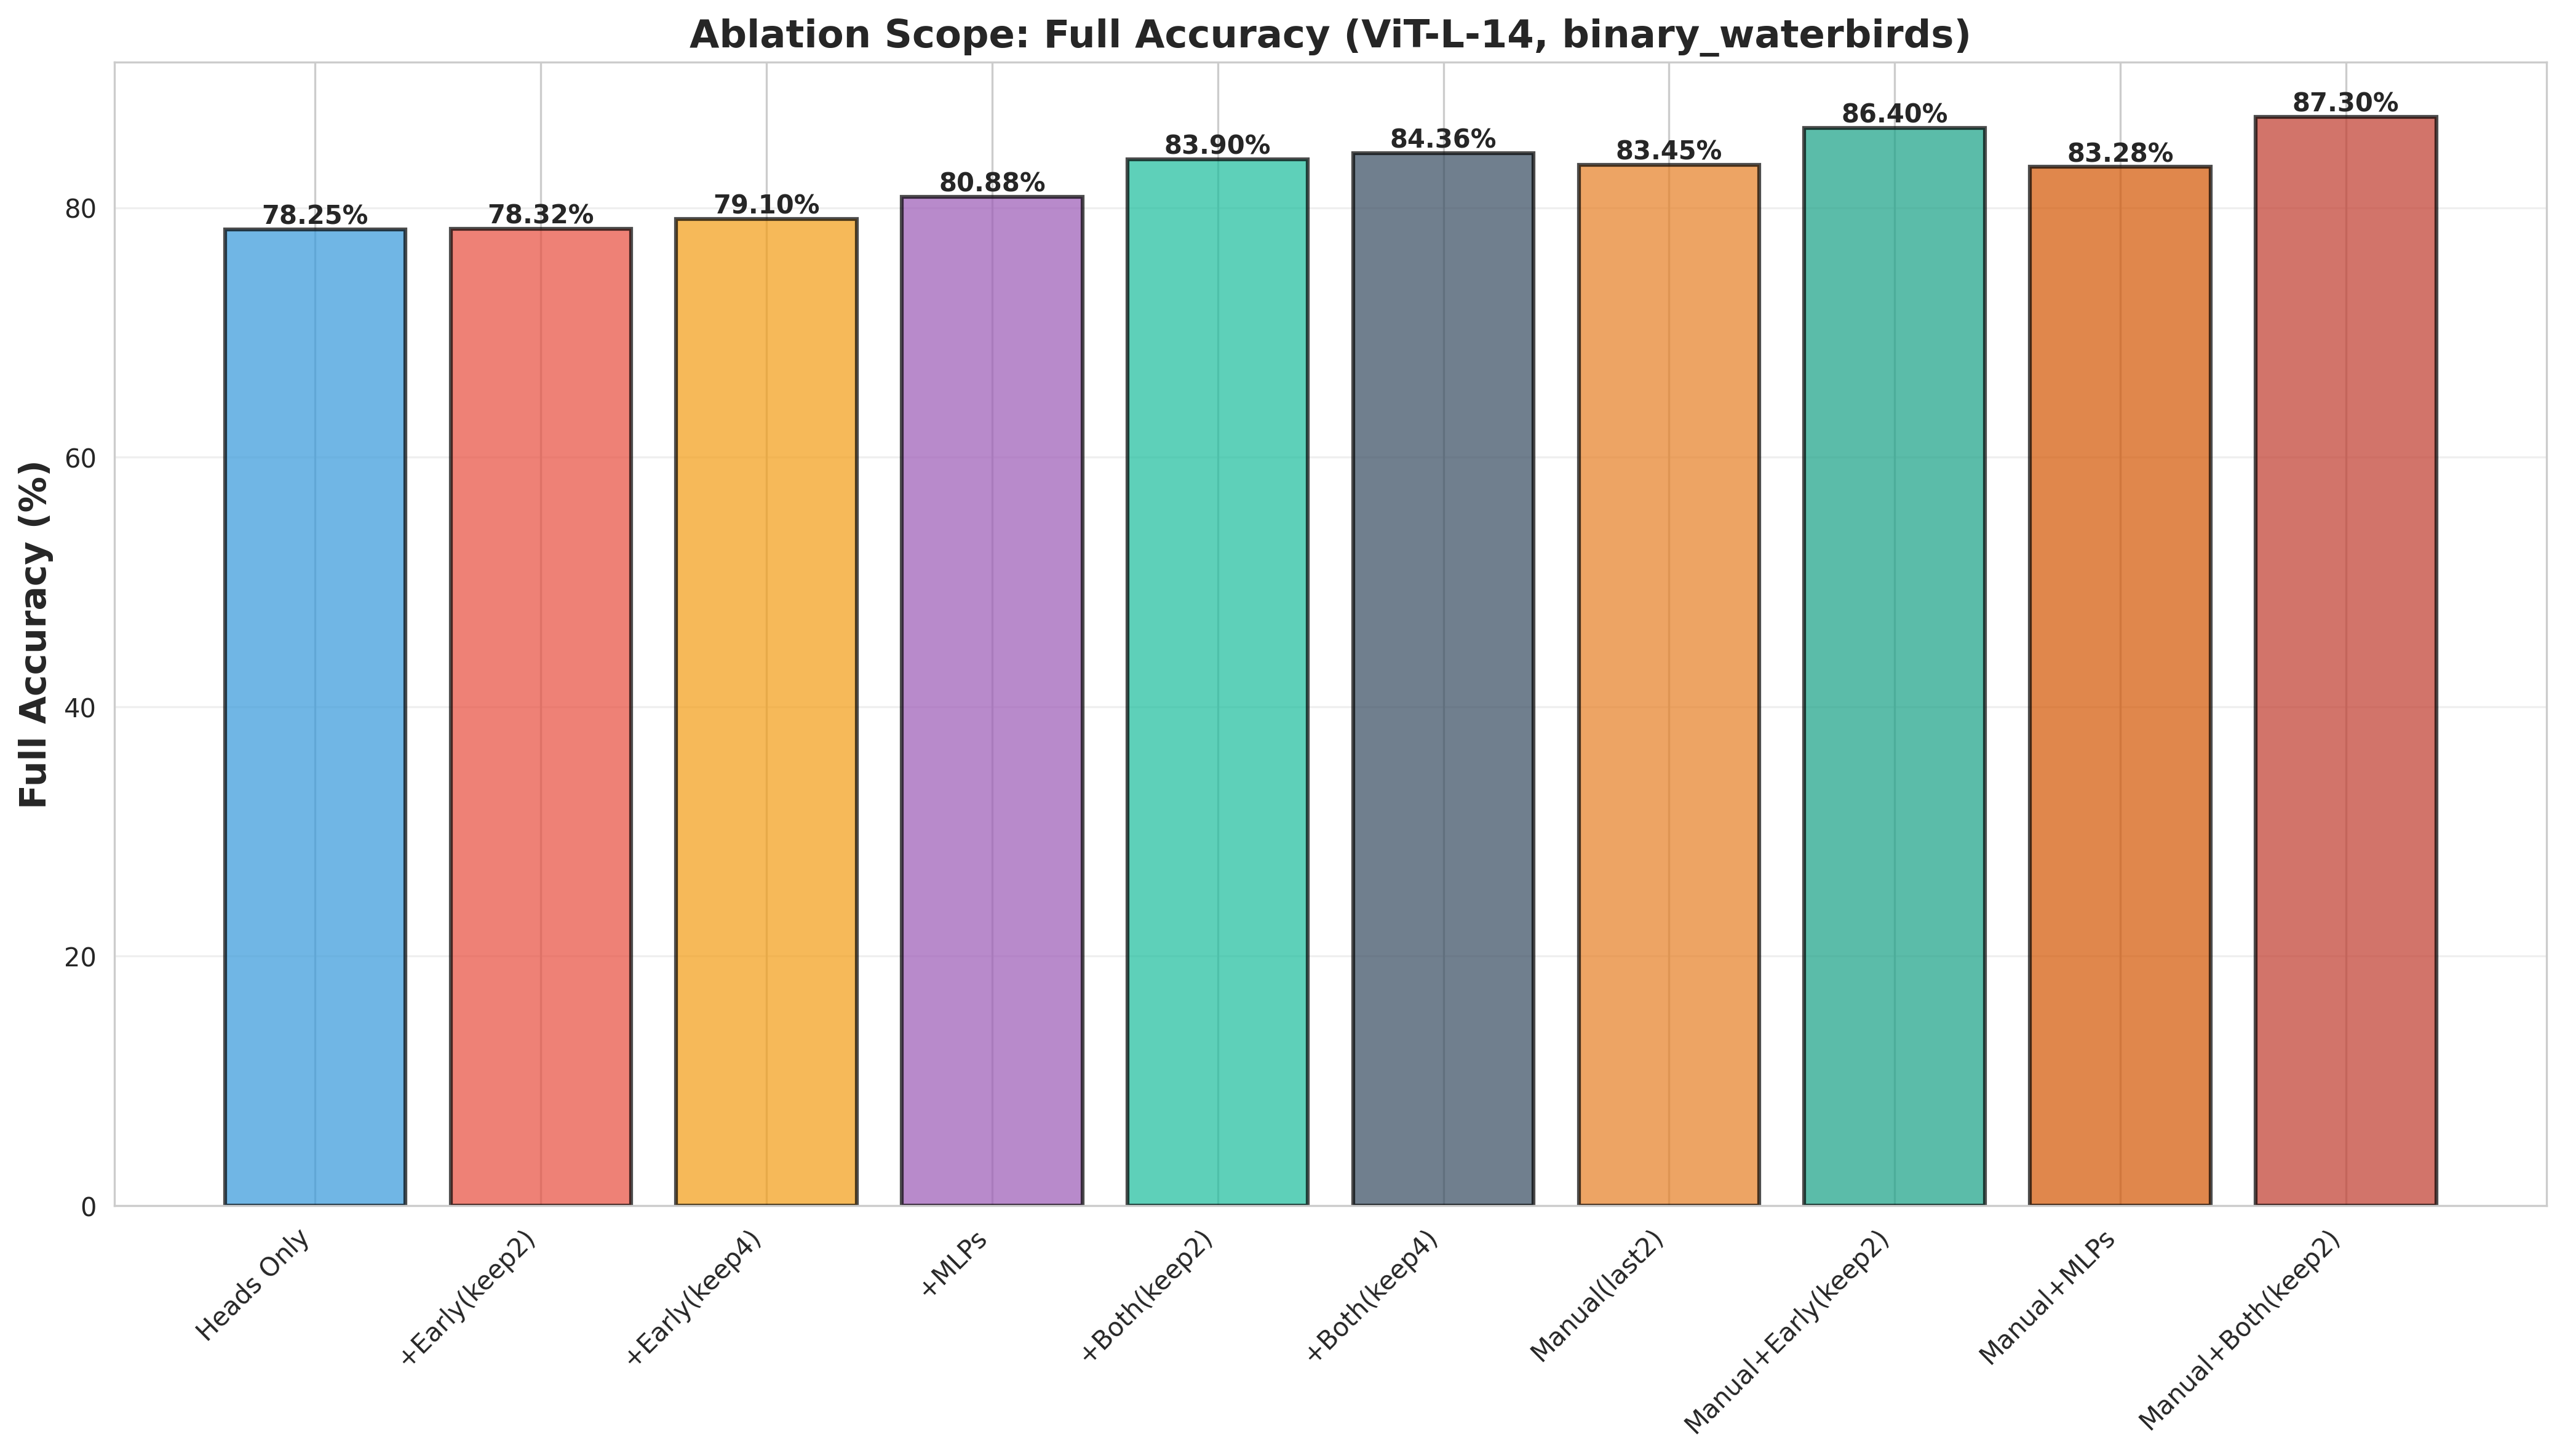

In [ ]:
from IPython.display import Image, display

image_path = './output_dir/results/analysis4a_ablation_scope_full_accuracy_ViT-L-14_binary_waterbirds.png'
display(Image(filename=image_path))

Full accuracy of different ablation scopes.
- **Heads Only** (Strategy 2 selected heads)
- **+Early Layers** (keep last 2 layers)
- **+Early Layers** (keep last 4 layers)
- **+MLPs**
- **+Early Layers + MLPs** (keep last 2 layers)
- **+Early Layers + MLPs** (keep last 4 layers)
- Manual selection variants

## Train with Decorrelation Loss

In [11]:
# load baseline model
!python train_with_decorrelation.py \
    --model ViT-L-14 \
    --pretrained laion2b_s32b_b82k \
    --dataset binary_waterbirds \
    --data_path ./waterbird_complete95_forest2water2/ \
    --batch_size 16 \
    --eval_batch_size 256 \
    --epochs 10 \
    --lr 1e-5 \
    --lambda_decorr 0 \
    --last_n_layers 1 \
    --train_last_n_layers 1 \
    --use_amp \
    --num_workers 8 \
    --device cuda:0 \
    --output_dir ./output_dir \
    --save_ckpt

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Freezing first 23 layers, training last 1 layers
Loading classifier from ./output_dir/binary_waterbirds_classifier_ViT-L-14.npy
Training batch size: 16, Evaluation batch size: 256
Model: ViT-L-14
Dataset: binary_waterbirds
Training samples: 4795
Validation samples: 5794
Lambda decorr: 0.0
Last N layers: 1
Using mixed precision: True
Trainable parameters: 13,384,704

Epoch 1/10
--------------------------------------------------
Training: 100% 300/300 [00:16<00:00, 17.82it/s]
Memory after training cleanup: Allocated=1.76GB, Reserved=1.82GB
Memory before evaluation: Allocated=1.76GB, Reserved=1.82GB
Evaluating: 100% 23/23 [01:06<00:00,  2.87s/it]
Memory after evaluation: Allocated=1.76GB, Reserved=1.82GB
Train Loss: 0.

In [ ]:
# train our model
!python train_with_decorrelation.py \
    --model ViT-L-14 \
    --pretrained laion2b_s32b_b82k \
    --dataset binary_waterbirds \
    --data_path ./waterbird_complete95_forest2water2/ \
    --batch_size 16 \
    --eval_batch_size 256 \
    --epochs 10 \
    --lr 1e-5 \
    --lambda_decorr 0.5 \
    --last_n_layers 1 \
    --train_last_n_layers 1 \
    --use_amp \
    --num_workers 8 \
    --device cuda:0 \
    --output_dir ./output_dir \
    --save_ckpt

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Freezing first 23 layers, training last 1 layers
Loading classifier from ./output_dir/binary_waterbirds_classifier_ViT-L-14.npy
Training batch size: 16, Evaluation batch size: 256
Model: ViT-L-14
Dataset: binary_waterbirds
Training samples: 4795
Validation samples: 5794
Lambda decorr: 0.5
Last N layers: 1
Using mixed precision: True
Trainable parameters: 13,384,704

Epoch 1/10
--------------------------------------------------
Training: 100% 300/300 [09:19<00:00,  1.86s/it]
Memory after training cleanup: Allocated=1.76GB, Reserved=1.84GB
Memory before evaluation: Allocated=1.76GB, Reserved=1.84GB
Evaluating: 100% 23/23 [01:05<00:00,  2.83s/it]
Memory after evaluation: Allocated=1.76GB, Reserved=1.84GB
Train Loss: 0.

In [12]:
!python compare_models.py \
    --model1_path ./output_dir/best_model_ViT-L-14_binary_waterbirds_no_decorr.pth \
    --model2_path ./output_dir/best_model_ViT-L-14_binary_waterbirds_decorr0.1_layers1.pth \
    --model1_name "Baseline (no decorr)" \
    --model2_name "With Decorrelation Loss" \
    --model ViT-L-14 \
    --pretrained laion2b_s32b_b82k \
    --dataset binary_waterbirds \
    --data_path ./waterbird_complete95_forest2water2/ \
    --batch_size 256 \
    --num_workers 8 \
    --device cuda:0 \
    --output_dir ./output_dir/comparison_results

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)

Loading Baseline (no decorr) from ./output_dir/best_model_ViT-L-14_binary_waterbirds_no_decorr.pth...
  Epoch: 4
  Val Accuracy: 92.27%
  Training args: lambda_decorr=0.0, last_n_layers=1
  Model loaded successfully!

Loading With Decorrelation Loss from ./output_dir/best_model_ViT-L-14_binary_waterbirds_decorr0.1_layers1.pth...
  Epoch: 8
  Val Accuracy: 91.75%
  Training args: lambda_decorr=0.1, last_n_layers=1
  Model loaded successfully!

Loading classifier from ./output_dir/comparison_results/binary_waterbirds_classifier_ViT-L-14.npy

Loaded scene attributes: 5794 samples
  Land scenes (0): 2897
  Water scenes (1): 2897

Dataset: binary_waterbirds
Validation samples: 5794
Batch size: 256

EVALUATING MODELS
Eva

## Use trained baseline model and apply user-guided ablation

In [ ]:
# compute prs
!python compute_prs.py \
    --model ViT-L-14 \
    --pretrained laion2b_s32b_b82k \
    --dataset binary_waterbirds \
    --data_path ./waterbird_complete95_forest2water2/ \
    --checkpoint ./output_dir/best_model_ViT-L-14_binary_waterbirds_no_decorr.pth \
    --output_dir ./output_dir \
    --batch_size 16 \
    --num_workers 8 \
    --device cuda:0

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)

Loading model from checkpoint: ./output_dir/best_model_ViT-L-14_binary_waterbirds_no_decorr.pth
  Epoch: 4
  Val Accuracy: 92.27%
  Training args: lambda_decorr=0.0, last_n_layers=1
  Model loaded successfully from checkpoint!
Model parameters: 427,616,513
Context length: 77
Vocab size: 49408
Len of res: 24
100% 363/363 [2:00:17<00:00, 19.88s/it]


In [9]:
# compute text prjection
!python compute_text_projection.py \
    --model ViT-L-14 \
    --pretrained laion2b_s32b_b82k \
    --dataset binary_waterbirds \
    --checkpoint ./output_dir/best_model_ViT-L-14_binary_waterbirds_no_decorr.pth \
    --output_dir ./output_dir \
    --device cuda:0

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
open_clip_pytorch_model.bin: 100% 1.71G/1.71G [00:04<00:00, 343MB/s] 

Loading model from checkpoint: ./output_dir/best_model_ViT-L-14_binary_waterbirds_no_decorr.pth
  Epoch: 4
  Val Accuracy: 92.27%
  Training args: lambda_decorr=0.0, last_n_layers=1
  Model loaded successfully from checkpoint!
Model parameters: 427,616,513
Context length: 77
Vocab size: 49408
/content/drive/MyDrive/ee546/clip_text_span-main/compute_text_projection.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():
100% 2/2 [00:00<00:00,  2.88it/s]

Saved classifier to: ./output_dir/binary_waterbirds_classifier_best_model_ViT-L-14_bin

In [15]:
# user-guided ablation
!python select_ablated_heads.py \
    --model ViT-L-14 \
    --dataset binary_waterbirds \
    --input_dir ./output_dir \
    --output_dir ./output_dir/comparison/ \
    --num_last_layers 2 \
    --classifier_file binary_waterbirds_classifier_best_model_ViT-L-14_binary_waterbirds_no_decorr.npy

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
SELECT HEADS AND RUN ABLATION

Loading attention features from: ./output_dir/binary_waterbirds_attn_ViT-L-14.npy
Model structure: 24 layers, 16 heads per layer
Analyzing last 2 layers: [22, 23]
Loading text features from: ./output_dir/image_descriptions_general_ViT-L-14.npy
Loading text descriptions from: text_descriptions/image_descriptions_general.txt

Computing top 1 text span for all heads in last 2 layers...
/content/drive/MyDrive/ee546/clip_text_span-main/compute_complete_text_set.py:37: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.aran